In [79]:
from kafka import KafkaConsumer
import pandas as pd
import json
import numpy as np
import os
from dotenv import load_dotenv
import matplotlib.pyplot as plt
load_dotenv()

True

In [32]:
KAFKA_PORT=os.getenv("KAFKA_PORT", 9092)
topic = "user-interactions"
consumer = KafkaConsumer(
    topic, 
    enable_auto_commit=True,
    value_deserializer=lambda x: json.loads(x.decode('utf-8')),
    auto_offset_reset='earliest',
    bootstrap_servers=['localhost:9092'])
messages=consumer.poll(timeout_ms=1000,max_records=10000)
df = []
for m in messages.values():
    for i in m:
        df.append(i.value)
df = pd.DataFrame(df)
# explode metadata col json
df = df.join(pd.json_normalize(df.pop("metadata"), sep=".").add_prefix("metadata_"))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141 entries, 0 to 140
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sessionId          141 non-null    object 
 1   eventType          141 non-null    object 
 2   ts                 141 non-null    int64  
 3   targetEl           14 non-null     object 
 4   targetUrl          1 non-null      object 
 5   metadata_path      141 non-null    object 
 6   metadata_referrer  6 non-null      object 
 7   metadata_x         14 non-null     float64
 8   metadata_y         14 non-null     float64
 9   metadata_scrollY   121 non-null    float64
dtypes: float64(3), int64(1), object(6)
memory usage: 11.1+ KB


In [51]:
df.groupby('sessionId').head()

,sessionId,eventType,ts,targetEl,targetUrl,metadata_path,metadata_referrer,metadata_x,metadata_y,metadata_scrollY
0,1761225843899-qaiwwwyj2o,pageview,1761226211163,NaN,NaN,/,,NaN,NaN,NaN
1,1761225843899-qaiwwwyj2o,click,1761226218090,MAIN,NaN,/,NaN,815.0,331.0,NaN
2,1761225843899-qaiwwwyj2o,click,1761226220890,MAIN,NaN,/,NaN,1129.0,605.0,NaN
3,1761225843899-qaiwwwyj2o,click,1761226225801,DIV,NaN,/,NaN,532.0,545.0,NaN
4,1761225843899-qaiwwwyj2o,click,1761226229364,DIV,NaN,/,NaN,481.0,399.0,NaN
5,1761227236286-e7mphcvw6t,pageview,1761227236426,NaN,NaN,/,,NaN,NaN,NaN
6,1761227236286-e7mphcvw6t,click,1761227239328,DIV,NaN,/,NaN,202.0,351.0,NaN
7,1761227236286-e7mphcvw6t,click,1761227244783,A,https://vercel.com/new?utm_source=create-next-...,/,NaN,377.0,723.0,NaN
8,1761828056433-0gz7aboz86h,pageview,1761828261783,NaN,NaN,/,,NaN,NaN,NaN
9,1761828056433-0gz7aboz86h,click,1761828266484,H1,NaN,/,NaN,527.0,169.0,NaN


In [35]:
sessions = list(set(df['sessionId'])); sessions

['1761225843899-qaiwwwyj2o',
 '1761828056433-0gz7aboz86h',
 '1761227236286-e7mphcvw6t']

In [ ]:
# map sessions to experiments

In [82]:
def build_transition_porba_matrix(df : pd.DataFrame):
    df = df.dropna(subset=['eventType'])
    events = list(df['eventType'])
    event_types = list(set(events))
    vocab = len(event_types)
    M = np.zeros((vocab,vocab))
    for eid in range(len(events)-1):
        event, event_n = events[eid], events[eid+1]
        M[event_types.index(event)][event_types.index(event_n)] += 1
    fig, ax = plt.subplots()
    im = ax.imshow(M)
    ax.set_xticks(range(vocab), labels=event_types,
              rotation=45, ha="right", rotation_mode="anchor")
    ax.set_yticks(range(vocab), labels=event_types)
    plt.show()
    return M/len(events)

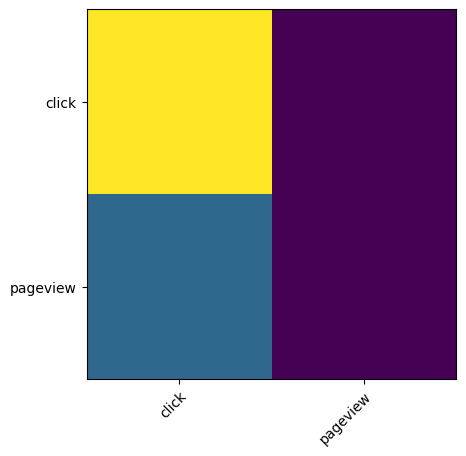

[[0.6 0. ]
 [0.2 0. ]]


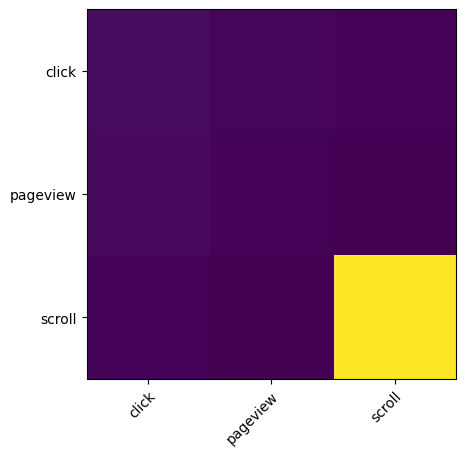

[[0.03007519 0.01503759 0.0075188 ]
 [0.02255639 0.0075188  0.        ]
 [0.0075188  0.         0.90225564]]


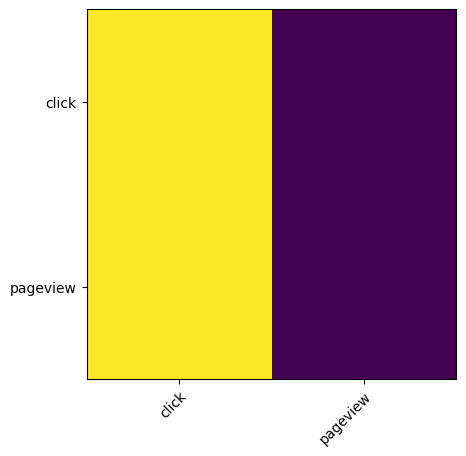

[[0.33333333 0.        ]
 [0.33333333 0.        ]]


In [84]:
def explore_session(session_id : str):
    subset = df.where(df['sessionId'] == session_id)
    matrix = build_transition_porba_matrix(subset)
    return matrix
for session in sessions:
    print(explore_session(session))